<a href="https://colab.research.google.com/github/PA-Pal601/CodeAlpha_Credit-Scoring-Model/blob/main/CodeAlpha_Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 Credit Scoring Model


**Models Used:**
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting (XGBoost)


---

## 📋 Table of Contents
1. [Setup & Imports](#1)
2. [Dataset Generation & Loading](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Feature Engineering](#4)
5. [Data Preprocessing](#5)
6. [Model Training](#6)
7. [Model Evaluation](#7)
8. [Model Comparison & Selection](#8)
9. [Feature Importance](#9)
10. [Prediction on New Data](#10)

## 1. Setup & Imports <a name='1'></a>

In [1]:
!pip install xgboost imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.pipeline import Pipeline

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Sklearn - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Plot settings
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2. Dataset Generation & Loading <a name='2'></a>

We simulate a realistic credit dataset with **10,000 records** and the following features:

| Feature | Description |
|---|---|
| `age` | Applicant age |
| `income` | Annual income (USD) |
| `employment_years` | Years at current employer |
| `num_credit_lines` | Number of open credit lines |
| `credit_utilization` | % of available credit used |
| `num_late_payments` | Count of late payments (last 2 years) |
| `num_defaults` | Count of defaults |
| `debt_to_income` | Debt-to-income ratio |
| `loan_amount` | Requested loan amount |
| `loan_purpose` | Purpose of loan |
| `home_ownership` | Renting / Owning |
| `credit_score_raw` | Raw credit bureau score |
| `creditworthy` | **Target: 1 = Good, 0 = Bad** |

In [2]:
np.random.seed(42)
N = 10_000

# --- Base Features ---
age                 = np.random.randint(18, 75, N)
income              = np.random.lognormal(mean=10.8, sigma=0.6, size=N).astype(int)  # ~$50k median
employment_years    = np.clip(np.random.exponential(scale=5, size=N), 0, 40).astype(int)
num_credit_lines    = np.random.randint(1, 15, N)
credit_utilization  = np.clip(np.random.beta(2, 5, N), 0, 1)  # skewed low
num_late_payments   = np.random.poisson(lam=0.8, size=N)
num_defaults        = np.random.choice([0, 1, 2, 3], N, p=[0.75, 0.14, 0.07, 0.04])
debt_to_income      = np.clip(np.random.beta(2, 6, N) * 1.5, 0, 1.5)
loan_amount         = np.random.randint(1_000, 80_000, N)
loan_purpose        = np.random.choice(['Personal', 'Auto', 'Home', 'Education', 'Business'], N,
                                        p=[0.30, 0.25, 0.20, 0.15, 0.10])
home_ownership      = np.random.choice(['Rent', 'Own', 'Mortgage'], N, p=[0.40, 0.25, 0.35])
credit_score_raw    = np.clip(np.random.normal(loc=670, scale=80, size=N), 300, 850).astype(int)

# --- Build Target with realistic logic ---
# Higher score = more likely to be creditworthy
score_component     = (credit_score_raw - 300) / 550  # normalize 0–1
income_component    = np.log1p(income) / np.log1p(income).max()
risk_score = (
    0.35 * score_component
    + 0.20 * income_component
    + 0.15 * (employment_years / 40)
    - 0.15 * (credit_utilization)
    - 0.10 * (num_late_payments / 10)
    - 0.15 * (num_defaults / 3)
    - 0.10 * (debt_to_income / 1.5)
)
prob_creditworthy   = 1 / (1 + np.exp(-5 * (risk_score - 0.35)))
creditworthy        = (np.random.rand(N) < prob_creditworthy).astype(int)

# --- Assemble DataFrame ---
df = pd.DataFrame({
    'age':                age,
    'income':             income,
    'employment_years':   employment_years,
    'num_credit_lines':   num_credit_lines,
    'credit_utilization': credit_utilization.round(4),
    'num_late_payments':  num_late_payments,
    'num_defaults':       num_defaults,
    'debt_to_income':     debt_to_income.round(4),
    'loan_amount':        loan_amount,
    'loan_purpose':       loan_purpose,
    'home_ownership':     home_ownership,
    'credit_score_raw':   credit_score_raw,
    'creditworthy':       creditworthy
})

# Add ~2% missing values to simulate real data
for col in ['income', 'employment_years', 'credit_utilization', 'debt_to_income']:
    mask = np.random.rand(N) < 0.02
    df.loc[mask, col] = np.nan

print(f'Dataset shape: {df.shape}')
print(f"\nClass distribution:\n{df['creditworthy'].value_counts(normalize=True).round(3) * 100}%")
df.head()

Dataset shape: (10000, 13)

Class distribution:
creditworthy
0    53.3
1    46.7
Name: proportion, dtype: float64%


,age,income,employment_years,num_credit_lines,credit_utilization,num_late_payments,num_defaults,debt_to_income,loan_amount,loan_purpose,home_ownership,credit_score_raw,creditworthy
0,56,27098.0,8.0,6,0.1017,0,0,0.3057,57387,Business,Mortgage,605,0
1,69,50951.0,1.0,10,0.0510,0,0,0.4843,1510,Business,Rent,580,1
2,46,16843.0,0.0,13,0.4038,2,0,0.3410,14760,Education,Own,586,0
3,32,60151.0,0.0,1,0.5559,0,0,0.9852,79836,Business,Own,731,0
4,60,18420.0,1.0,10,0.0905,0,0,0.9722,22336,Personal,Mortgage,774,1


## 3. Exploratory Data Analysis (EDA) <a name='3'></a>

In [3]:
# --- Basic Info ---
print('=== Dataset Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 10000 non-null  int64  
 1   income              9787 non-null   float64
 2   employment_years    9804 non-null   float64
 3   num_credit_lines    10000 non-null  int64  
 4   credit_utilization  9808 non-null   float64
 5   num_late_payments   10000 non-null  int64  
 6   num_defaults        10000 non-null  int64  
 7   debt_to_income      9778 non-null   float64
 8   loan_amount         10000 non-null  int64  
 9   loan_purpose        10000 non-null  object 
 10  home_ownership      10000 non-null  object 
 11  credit_score_raw    10000 non-null  int64  
 12  creditworthy        10000 non-null  int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 1015.8+ KB

=== Descriptive Statistics ===


,age,income,employment_years,num_credit_lines,credit_utilization,num_late_payments,num_defaults,debt_to_income,loan_amount,credit_score_raw,creditworthy
count,10000.00,9787.00,9804.00,10000.00,9808.00,10000.00,10000.00,9778.00,10000.00,10000.00,10000.00
mean,46.17,58607.38,4.55,7.61,0.29,0.79,0.40,0.38,40821.72,669.70,0.47
std,16.42,38306.32,5.00,4.01,0.16,0.88,0.79,0.22,22996.76,78.23,0.50
min,18.00,5334.00,0.00,1.00,0.00,0.00,0.00,0.01,1004.00,391.00,0.00
25%,32.00,32644.50,1.00,4.00,0.16,0.00,0.00,0.21,21090.50,617.00,0.00
50%,46.00,49015.00,3.00,8.00,0.27,1.00,0.00,0.34,40994.00,670.00,0.00
75%,61.00,73495.00,6.00,11.00,0.39,1.00,0.00,0.52,60686.50,723.00,1.00
max,74.00,557674.00,40.00,14.00,0.90,6.00,3.00,1.25,79992.00,850.00,1.00


Missing Values:
income                213
employment_years      196
credit_utilization    192
debt_to_income        222
dtype: int64


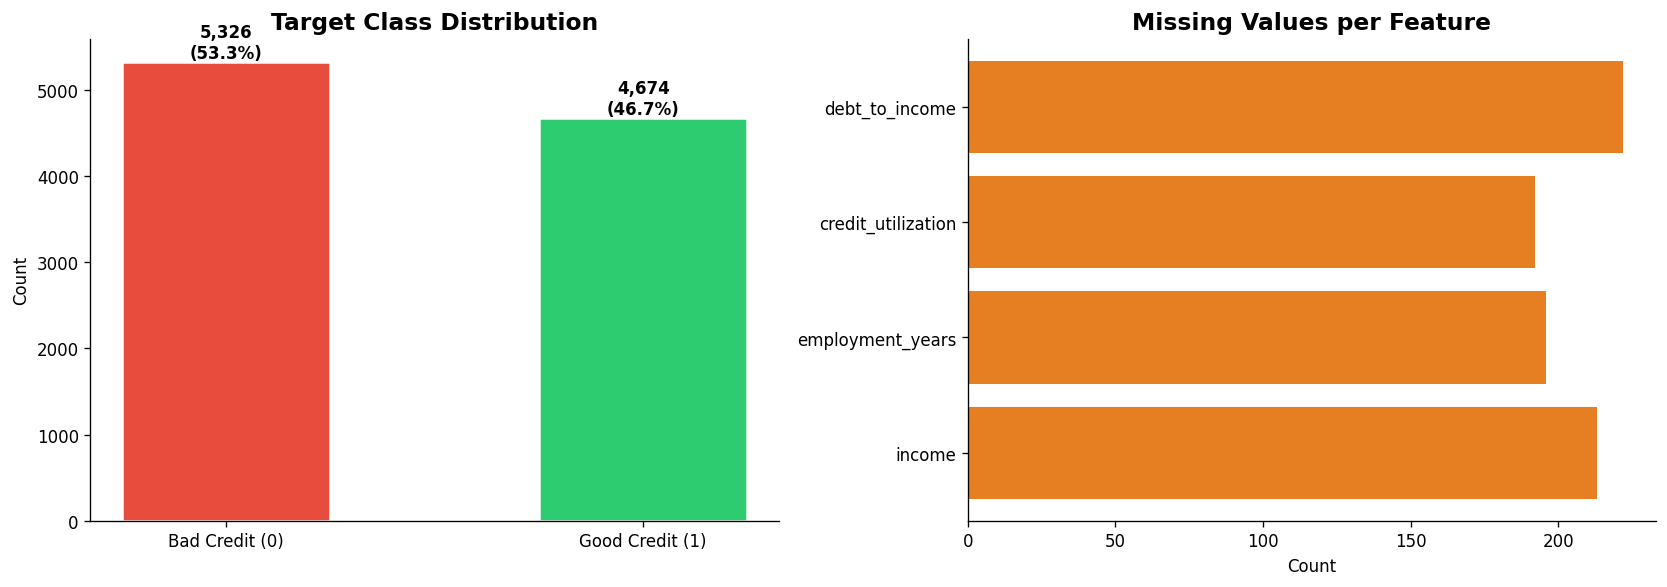

In [4]:
# --- Missing Values ---
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing Values:')
print(missing)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class Distribution
counts = df['creditworthy'].value_counts()
axes[0].bar(['Bad Credit (0)', 'Good Credit (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/N*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

# Missing values bar
if len(missing) > 0:
    axes[1].barh(missing.index, missing.values, color='#e67e22')
    axes[1].set_title('Missing Values per Feature', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=14)
    axes[1].set_title('Missing Values', fontsize=14)

plt.tight_layout()
plt.show()

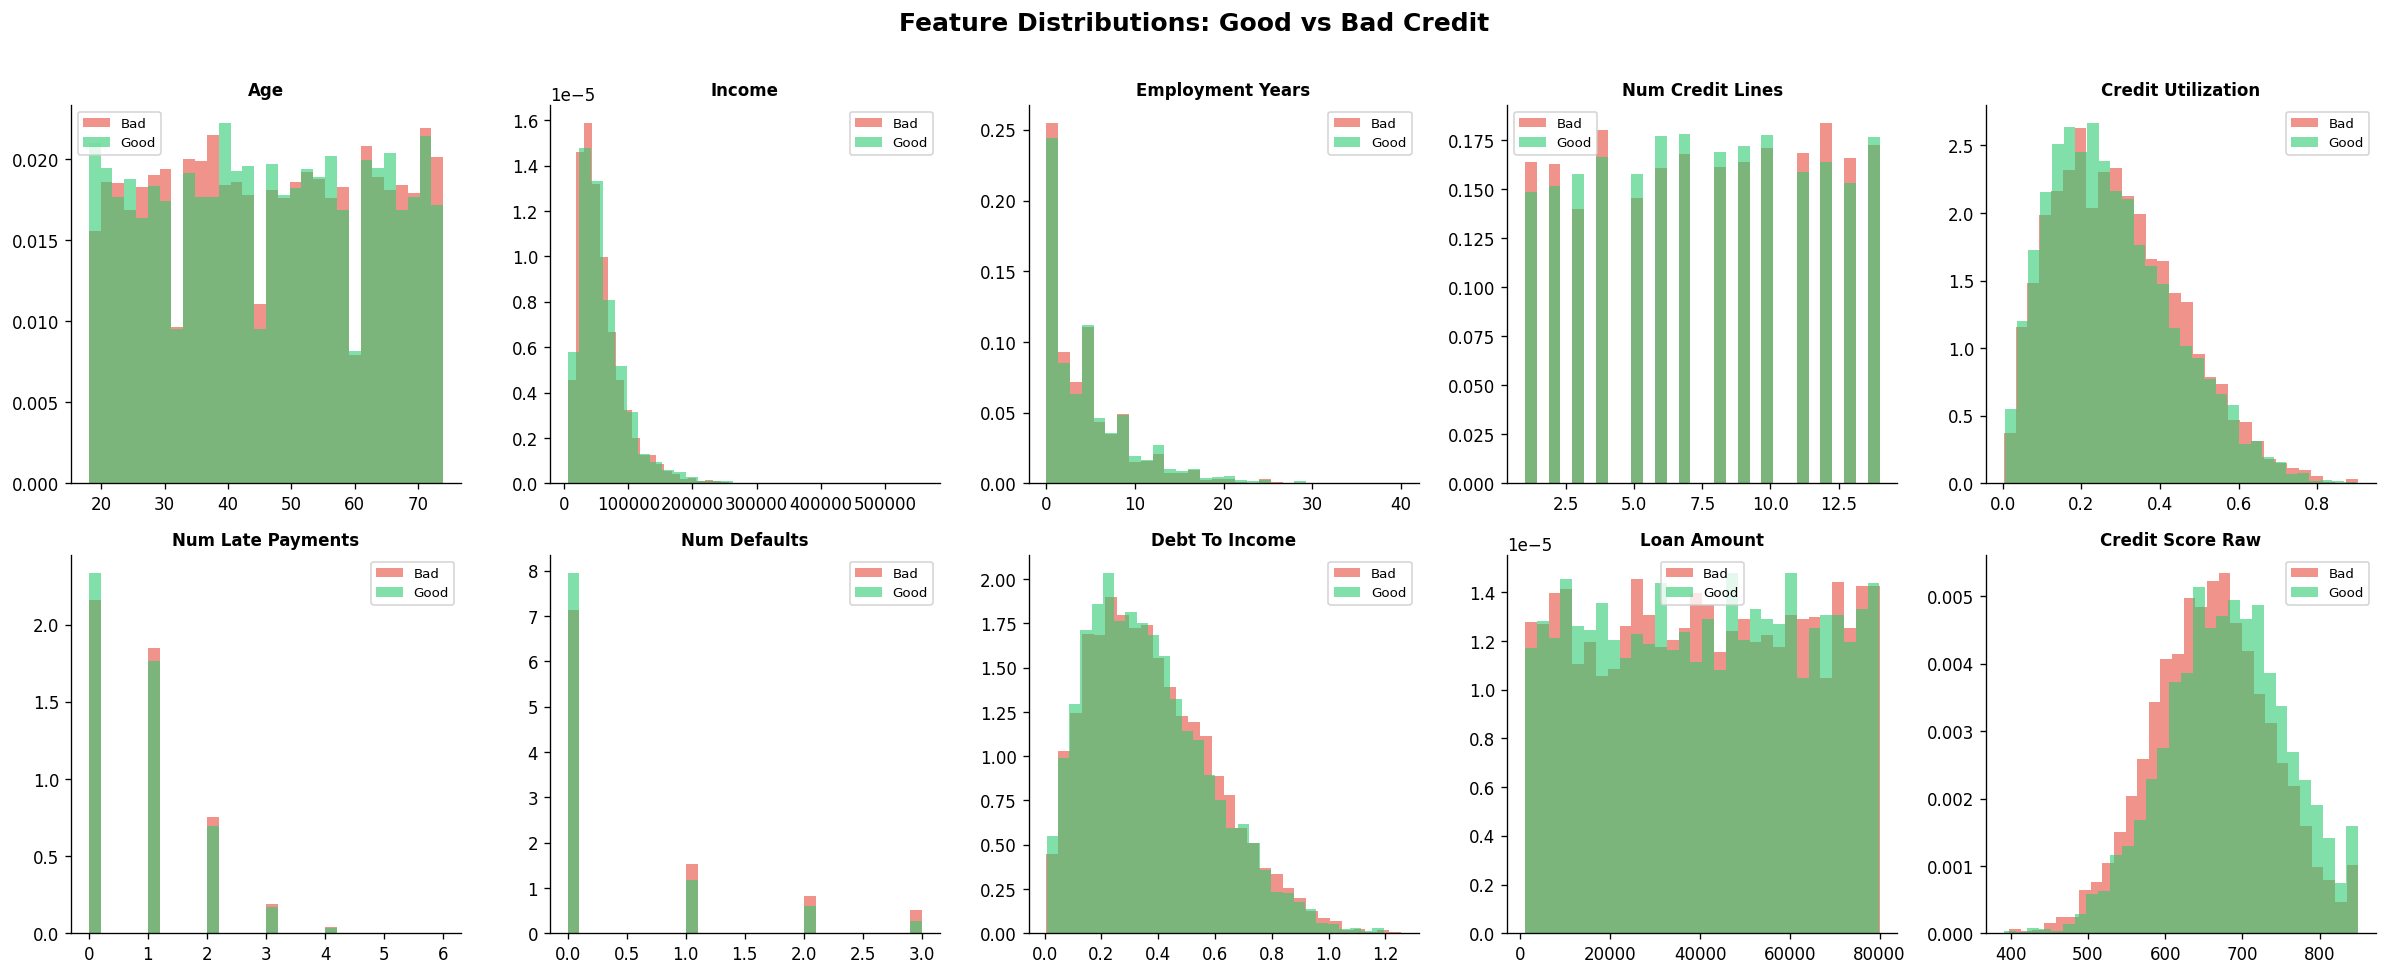

In [5]:
# --- Numerical Feature Distributions by Target ---
num_cols = ['age', 'income', 'employment_years', 'num_credit_lines',
            'credit_utilization', 'num_late_payments', 'num_defaults',
            'debt_to_income', 'loan_amount', 'credit_score_raw']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for cls, color, label in [(0, '#e74c3c', 'Bad'), (1, '#2ecc71', 'Good')]:
        data = df[df['creditworthy'] == cls][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Good vs Bad Credit', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

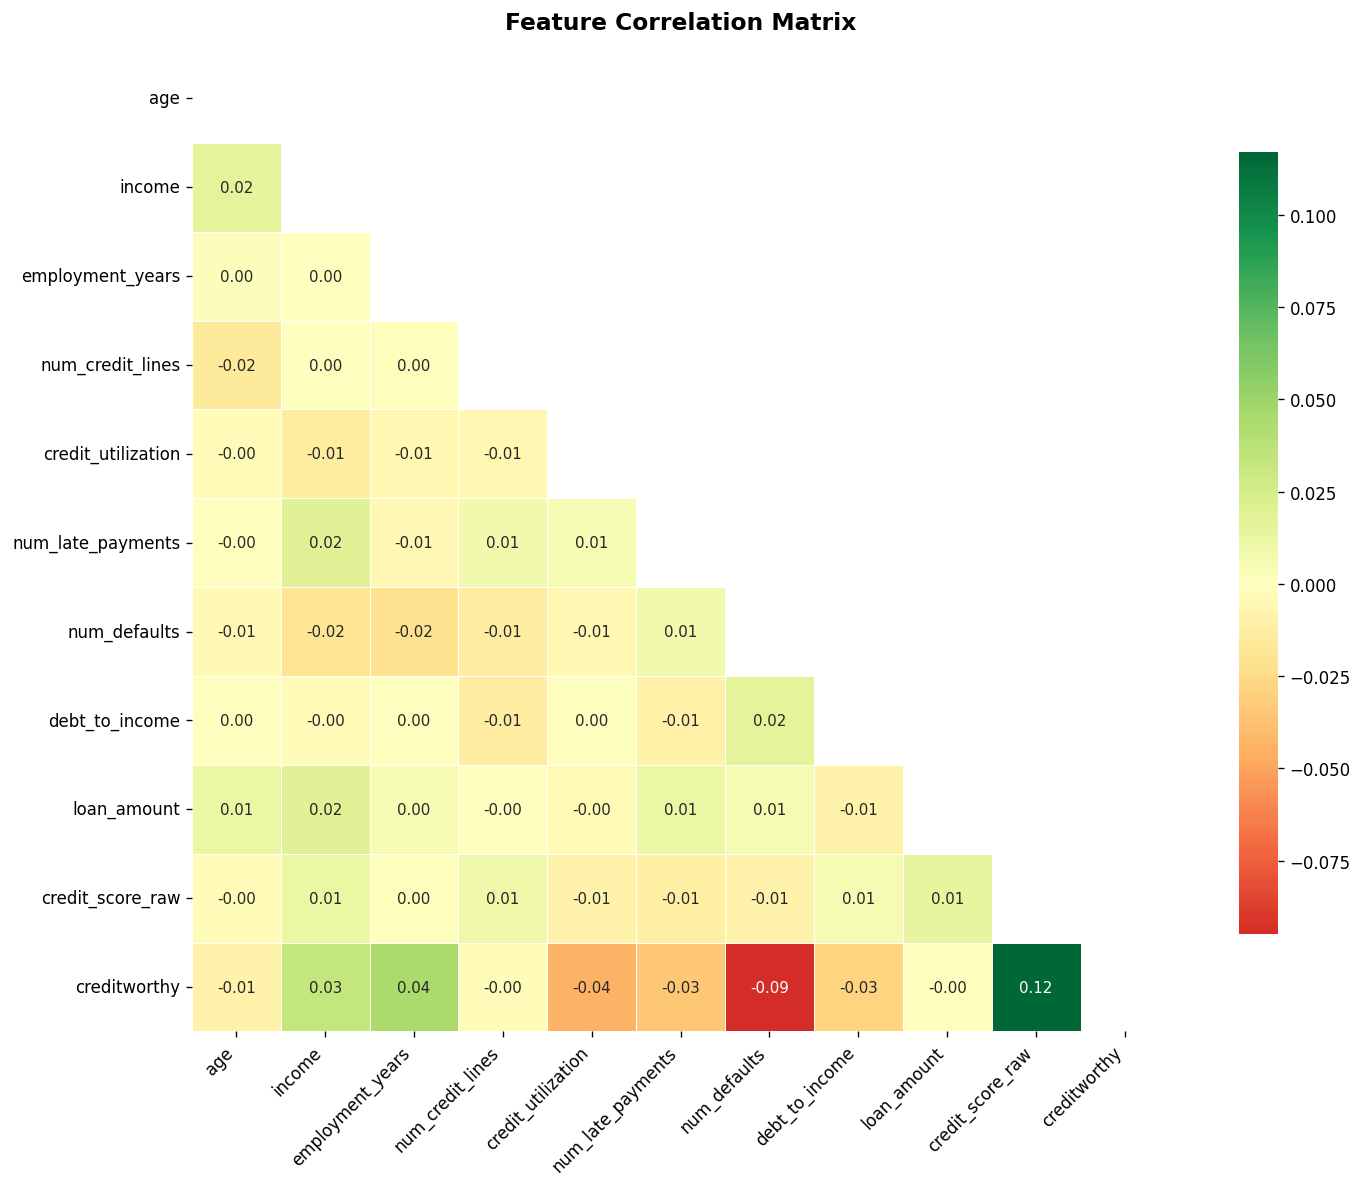

In [6]:
# --- Correlation Heatmap (numerical only) ---
corr = df[num_cols + ['creditworthy']].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

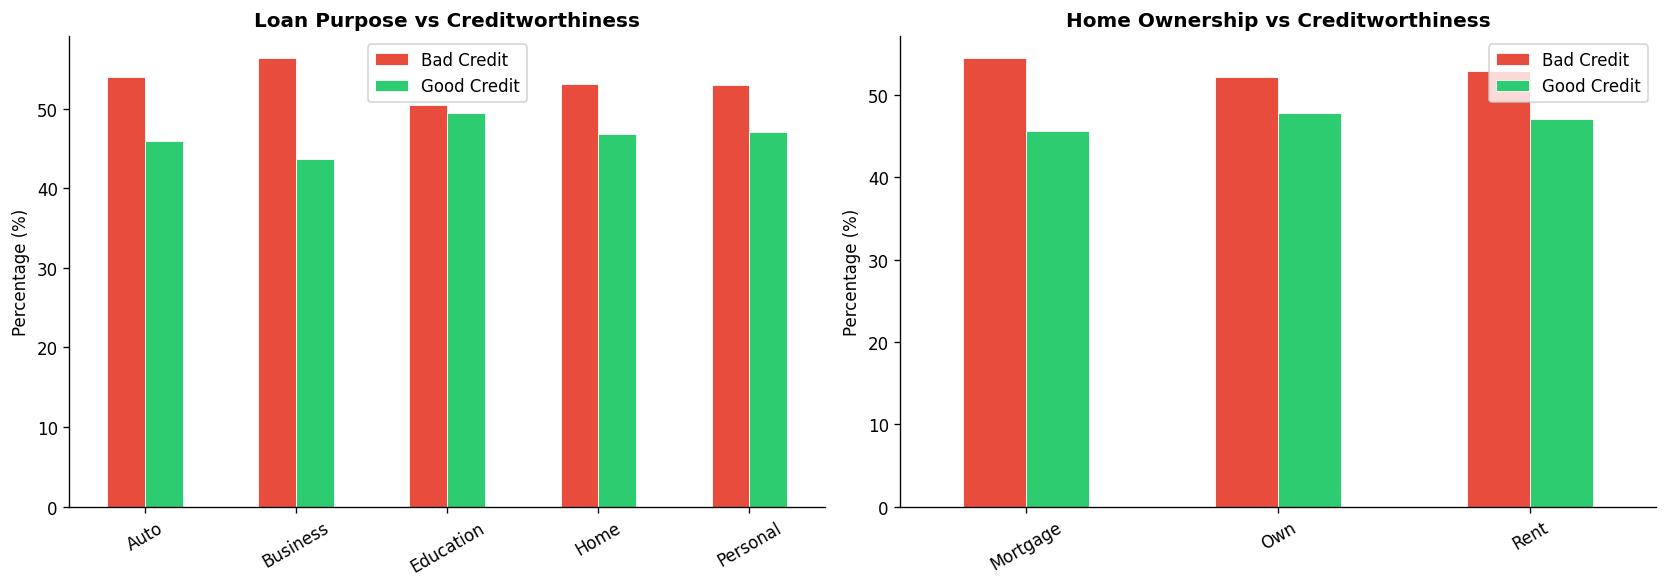

In [7]:
# --- Categorical Features vs Target ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['loan_purpose', 'home_ownership']):
    ct = pd.crosstab(df[col], df['creditworthy'], normalize='index') * 100
    ct.columns = ['Bad Credit', 'Good Credit']
    ct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'],
            edgecolor='white', linewidth=0.5)
    ax.set_title(f'{col.replace("_", " ").title()} vs Creditworthiness',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Feature Engineering <a name='4'></a>

In [8]:
df_eng = df.copy()

# --- Impute Missing Values ---
for col in ['income', 'employment_years', 'credit_utilization', 'debt_to_income']:
    df_eng[col].fillna(df_eng[col].median(), inplace=True)

# --- New Engineered Features ---

# 1. Income per loan: higher = safer
df_eng['income_to_loan_ratio'] = df_eng['income'] / (df_eng['loan_amount'] + 1)

# 2. Risk score: composite of bad payment behaviors
df_eng['payment_risk_score'] = (df_eng['num_late_payments'] * 0.4
                                + df_eng['num_defaults'] * 1.0
                                + df_eng['credit_utilization'] * 0.6)

# 3. Stability index: age + employment years
df_eng['stability_index'] = (df_eng['age'] * 0.4 + df_eng['employment_years'] * 0.6) / 10

# 4. Log-transform skewed features
df_eng['log_income'] = np.log1p(df_eng['income'])
df_eng['log_loan_amount'] = np.log1p(df_eng['loan_amount'])

# 5. Credit score bucket
df_eng['credit_bucket'] = pd.cut(
    df_eng['credit_score_raw'],
    bins=[299, 579, 669, 739, 799, 851],
    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']
)

# 6. Binary: any default ever?
df_eng['has_default'] = (df_eng['num_defaults'] > 0).astype(int)

# 7. Binary: high utilization (>70%)
df_eng['high_utilization'] = (df_eng['credit_utilization'] > 0.70).astype(int)

print('New features added:')
new_features = ['income_to_loan_ratio', 'payment_risk_score', 'stability_index',
                'log_income', 'log_loan_amount', 'credit_bucket', 'has_default', 'high_utilization']
print(df_eng[new_features].describe().round(3))

New features added:
       income_to_loan_ratio  payment_risk_score  stability_index  log_income  \
count             10000.000           10000.000        10000.000   10000.000   
mean                  3.238               0.889            2.118      10.800   
std                   7.399               0.872            0.721       0.592   
min                   0.109               0.002            0.720       8.582   
25%                   0.757               0.226            1.540      10.405   
50%                   1.335               0.582            2.120      10.800   
75%                   2.786               1.180            2.685      11.196   
max                 202.046               5.119            5.140      13.232   

       log_loan_amount  has_default  high_utilization  
count        10000.000    10000.000         10000.000  
mean            10.352        0.248             0.011  
std              0.871        0.432             0.103  
min              6.913        0.000

## 5. Data Preprocessing <a name='5'></a>

In [9]:
# --- Encode Categorical Variables ---
cat_cols = ['loan_purpose', 'home_ownership', 'credit_bucket']
df_model = pd.get_dummies(df_eng, columns=cat_cols, drop_first=False)

# --- Define Features & Target ---
drop_cols = ['creditworthy', 'credit_score_raw']  # drop raw score (data leakage risk)
X = df_model.drop(columns=drop_cols)
y = df_model['creditworthy']

print(f'Feature matrix shape: {X.shape}')
print(f'\nFeatures ({len(X.columns)}):')
print(list(X.columns))

# --- Train / Test Split (Stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')

# --- Apply SMOTE to handle class imbalance ---
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f'\nAfter SMOTE — Train size: {X_train_sm.shape}')
print(f'Class balance: {pd.Series(y_train_sm).value_counts(normalize=True).round(3).to_dict()}')

# --- Scale ---
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)
print('\n✅ Preprocessing complete!')

Feature matrix shape: (10000, 29)

Features (29):
['age', 'income', 'employment_years', 'num_credit_lines', 'credit_utilization', 'num_late_payments', 'num_defaults', 'debt_to_income', 'loan_amount', 'income_to_loan_ratio', 'payment_risk_score', 'stability_index', 'log_income', 'log_loan_amount', 'has_default', 'high_utilization', 'loan_purpose_Auto', 'loan_purpose_Business', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal', 'home_ownership_Mortgage', 'home_ownership_Own', 'home_ownership_Rent', 'credit_bucket_Poor', 'credit_bucket_Fair', 'credit_bucket_Good', 'credit_bucket_Very Good', 'credit_bucket_Exceptional']

Train: (8000, 29), Test: (2000, 29)
Train class balance: {0: 0.533, 1: 0.467}

After SMOTE — Train size: (8522, 29)
Class balance: {1: 0.5, 0: 0.5}

✅ Preprocessing complete!


## 6. Model Training <a name='6'></a>

In [10]:
# --- Define Models ---
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=0.5, solver='lbfgs', random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=20, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=10,
        n_jobs=-1, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=5,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        use_label_encoder=False, eval_metric='logloss',
        n_jobs=-1, random_state=42, verbosity=0
    )
}

# --- Train & Evaluate with Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('Training models...\n')
for name, model in models.items():
    # Use scaled data for LR, raw for tree-based
    if name == 'Logistic Regression':
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train_sm, X_test

    # Cross-validation ROC-AUC
    cv_scores = cross_val_score(model, Xtr, y_train_sm, cv=cv,
                                 scoring='roc_auc', n_jobs=-1)
    # Fit on full training set
    model.fit(Xtr, y_train_sm)

    # Predictions
    y_pred      = model.predict(Xte)
    y_prob      = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'model':      model,
        'y_pred':     y_pred,
        'y_prob':     y_prob,
        'accuracy':   accuracy_score(y_test, y_pred),
        'precision':  precision_score(y_test, y_pred),
        'recall':     recall_score(y_test, y_pred),
        'f1':         f1_score(y_test, y_pred),
        'roc_auc':    roc_auc_score(y_test, y_prob),
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std':  cv_scores.std(),
        'Xte':        Xte
    }

    print(f'  ✓ {name:22s} | CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test AUC: {results[name]["roc_auc"]:.4f}')

print('\n✅ All models trained!')

Training models...

  ✓ Logistic Regression    | CV AUC: 0.6305 ± 0.0115 | Test AUC: 0.6040
  ✓ Decision Tree          | CV AUC: 0.5849 ± 0.0104 | Test AUC: 0.5601
  ✓ Random Forest          | CV AUC: 0.6185 ± 0.0054 | Test AUC: 0.5874
  ✓ Gradient Boosting      | CV AUC: 0.6130 ± 0.0091 | Test AUC: 0.5758
  ✓ XGBoost                | CV AUC: 0.6118 ± 0.0119 | Test AUC: 0.5639

✅ All models trained!


## 7. Model Evaluation <a name='7'></a>

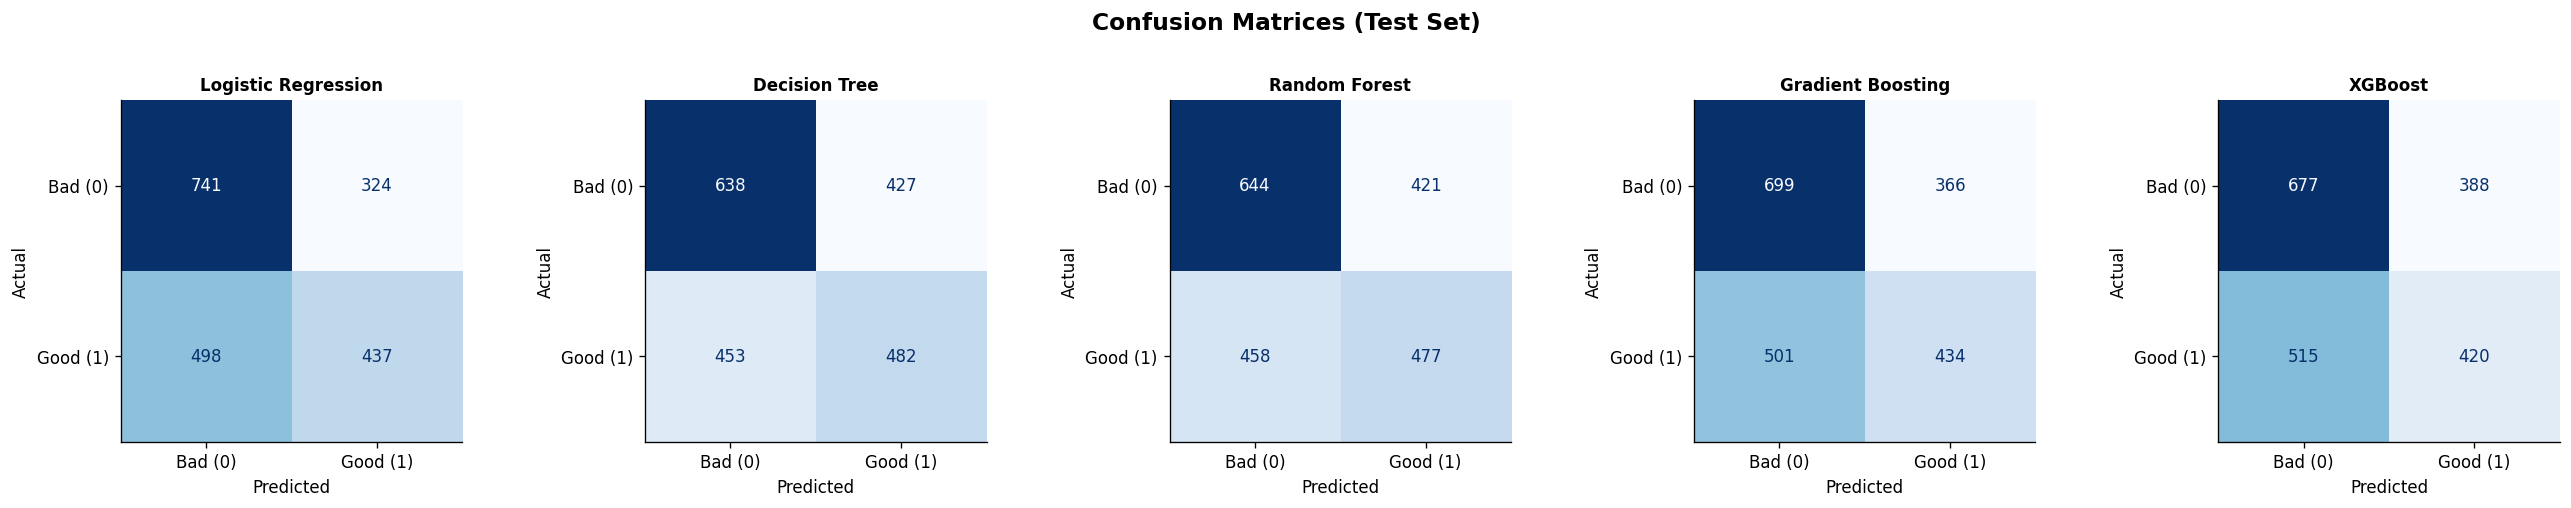

In [11]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Bad (0)', 'Good (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices (Test Set)', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

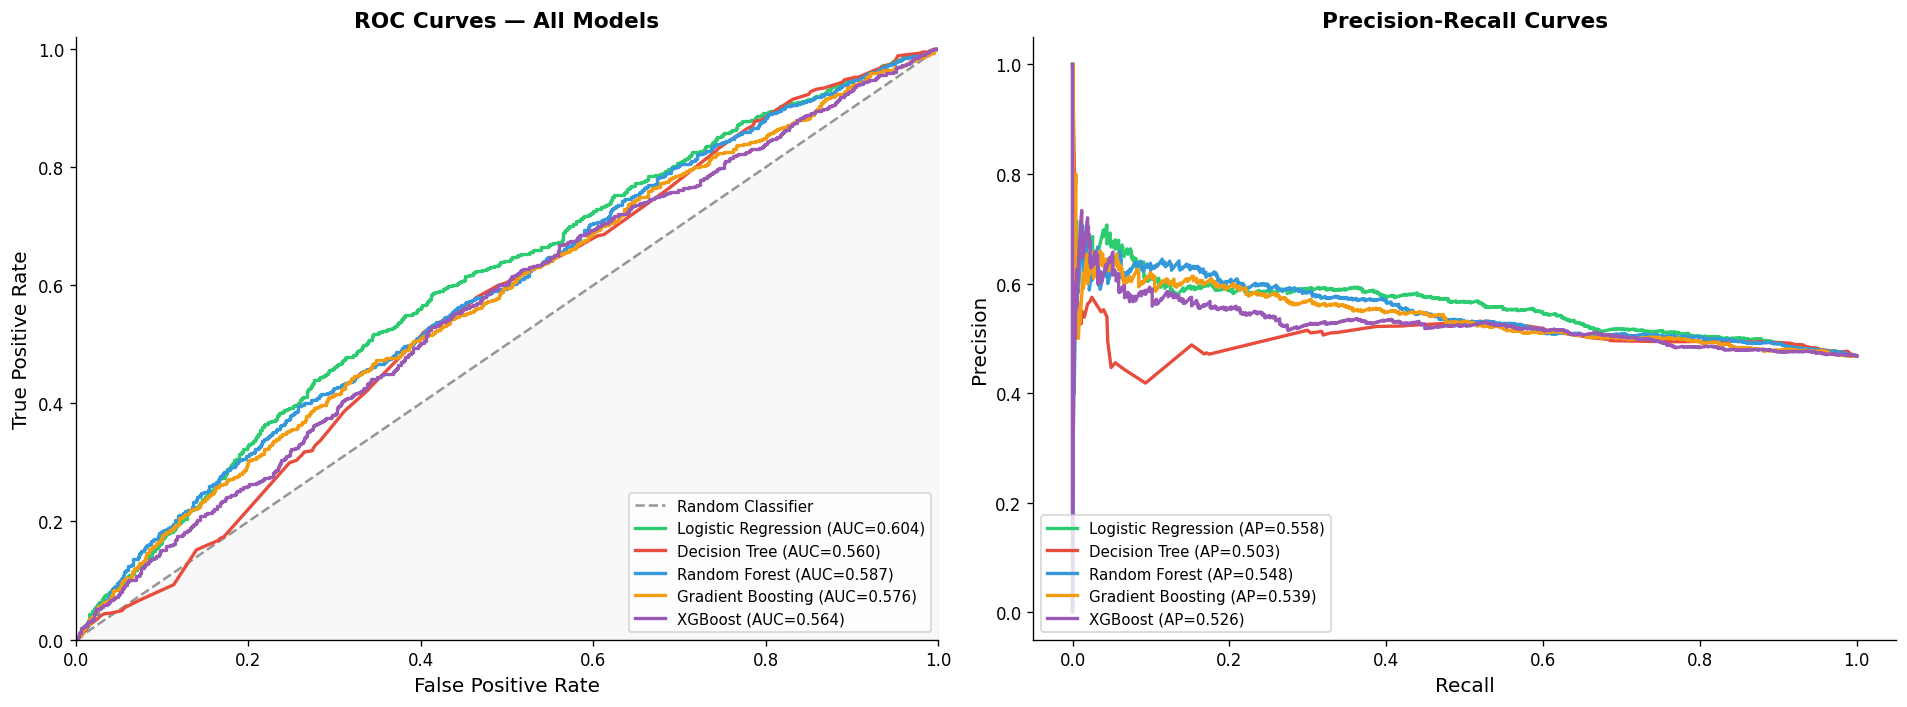

In [12]:
# --- ROC Curves ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Individual ROC curves
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')
for (name, res), color in zip(results.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC={res['roc_auc']:.3f})")
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

# Right: Precision-Recall Curves
ax2 = axes[1]
for (name, res), color in zip(results.items(), PALETTE):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    ax2.plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.3f})")
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax2.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
# --- Classification Reports ---
for name, res in results.items():
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(y_test, res['y_pred'],
                                  target_names=['Bad Credit', 'Good Credit']))


  Logistic Regression
              precision    recall  f1-score   support

  Bad Credit       0.60      0.70      0.64      1065
 Good Credit       0.57      0.47      0.52       935

    accuracy                           0.59      2000
   macro avg       0.59      0.58      0.58      2000
weighted avg       0.59      0.59      0.58      2000


  Decision Tree
              precision    recall  f1-score   support

  Bad Credit       0.58      0.60      0.59      1065
 Good Credit       0.53      0.52      0.52       935

    accuracy                           0.56      2000
   macro avg       0.56      0.56      0.56      2000
weighted avg       0.56      0.56      0.56      2000


  Random Forest
              precision    recall  f1-score   support

  Bad Credit       0.58      0.60      0.59      1065
 Good Credit       0.53      0.51      0.52       935

    accuracy                           0.56      2000
   macro avg       0.56      0.56      0.56      2000
weighted avg     

## 8. Model Comparison & Selection <a name='8'></a>

In [14]:
# --- Summary Table ---
summary_df = pd.DataFrame([
    {
        'Model':       name,
        'Accuracy':    f"{res['accuracy']:.4f}",
        'Precision':   f"{res['precision']:.4f}",
        'Recall':      f"{res['recall']:.4f}",
        'F1-Score':    f"{res['f1']:.4f}",
        'ROC-AUC':     f"{res['roc_auc']:.4f}",
        'CV AUC Mean': f"{res['cv_auc_mean']:.4f}",
        'CV AUC Std':  f"±{res['cv_auc_std']:.4f}",
    }
    for name, res in results.items()
])

print('\n📊 MODEL COMPARISON SUMMARY')
print('=' * 95)
print(summary_df.to_string(index=False))
print('=' * 95)

# Find best model
best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\n🏆 Best Model: {best_name} (ROC-AUC = {results[best_name]["roc_auc"]:.4f})')


📊 MODEL COMPARISON SUMMARY
              Model Accuracy Precision Recall F1-Score ROC-AUC CV AUC Mean CV AUC Std
Logistic Regression   0.5890    0.5742 0.4674   0.5153  0.6040      0.6305    ±0.0115
      Decision Tree   0.5600    0.5303 0.5155   0.5228  0.5601      0.5849    ±0.0104
      Random Forest   0.5605    0.5312 0.5102   0.5205  0.5874      0.6185    ±0.0054
  Gradient Boosting   0.5665    0.5425 0.4642   0.5003  0.5758      0.6130    ±0.0091
            XGBoost   0.5485    0.5198 0.4492   0.4819  0.5639      0.6118    ±0.0119

🏆 Best Model: Logistic Regression (ROC-AUC = 0.6040)


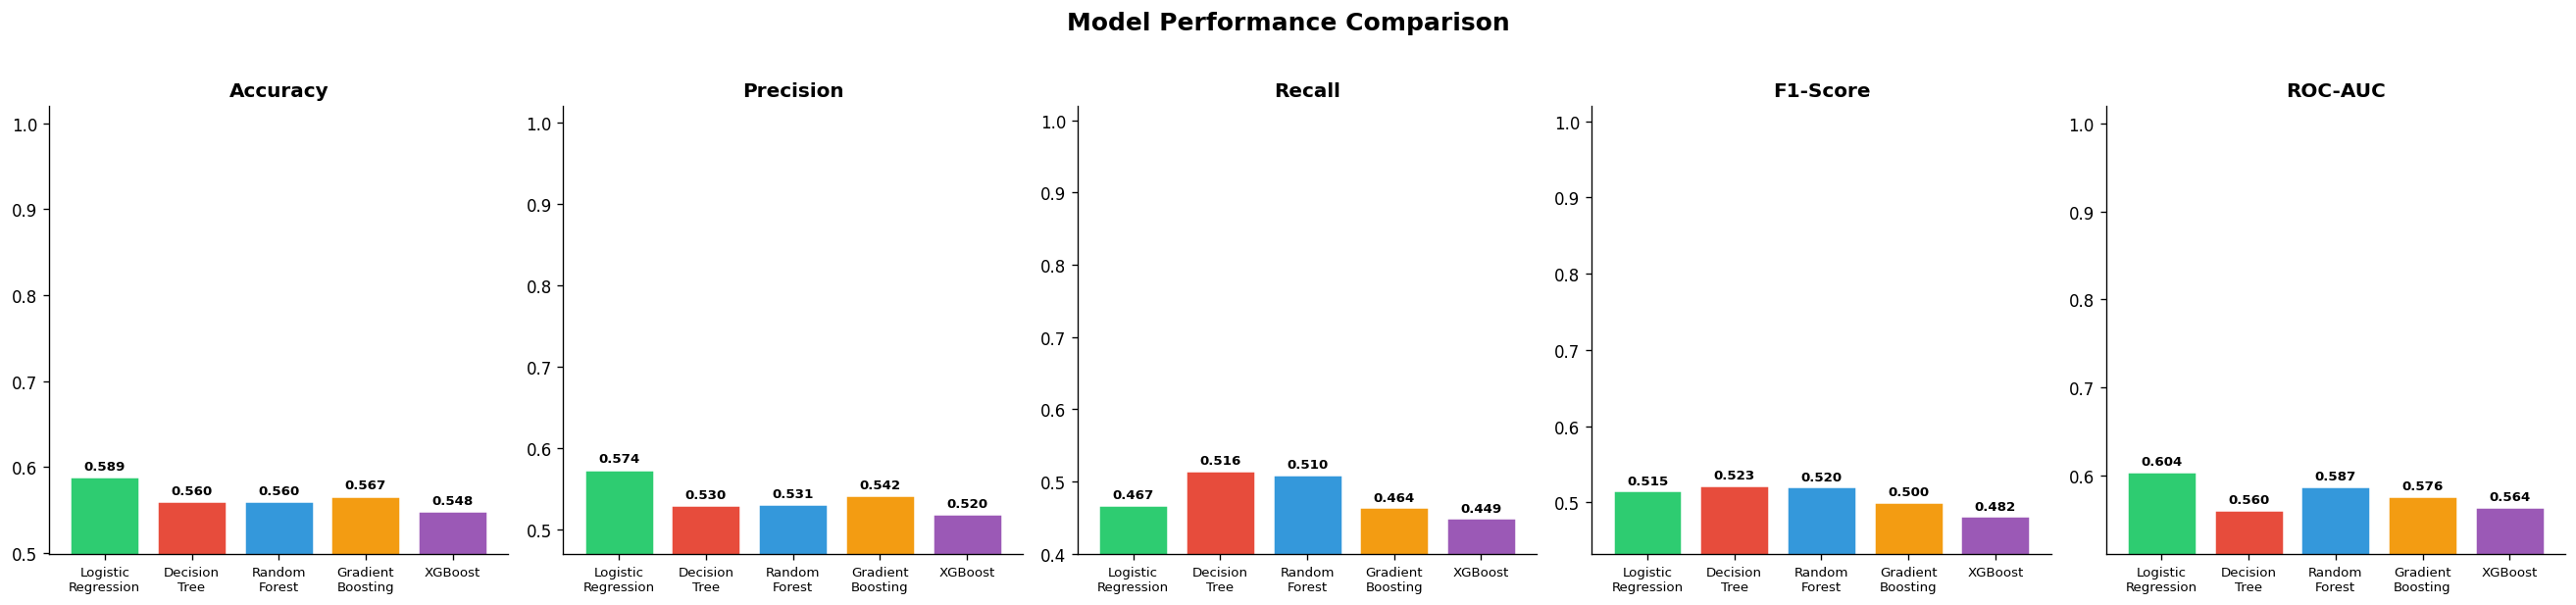

In [15]:
# --- Visual Comparison ---
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = list(results.keys())

fig, axes = plt.subplots(1, len(metrics), figsize=(22, 5), sharey=False)

for ax, metric, label in zip(axes, metrics, metric_labels):
    values = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, values, color=PALETTE, edgecolor='white', linewidth=1.5)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim([max(0, min(values) - 0.05), 1.02])
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Feature Importance <a name='9'></a>

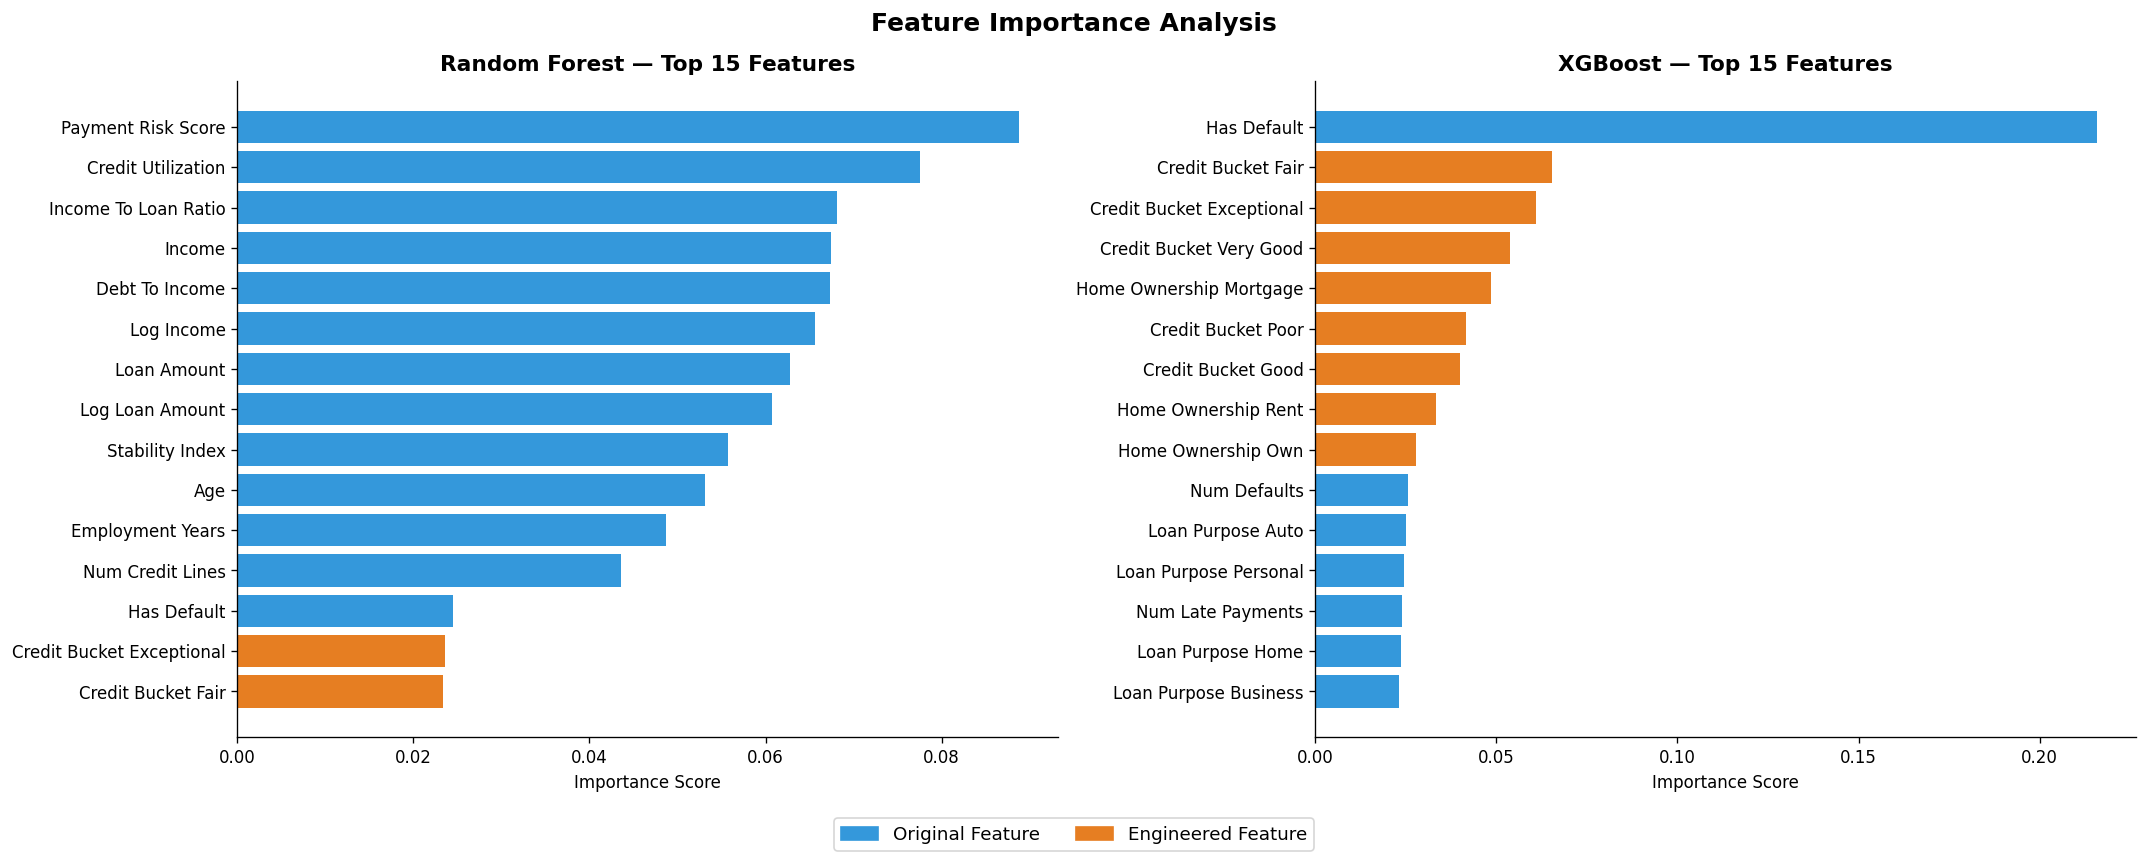

In [16]:
# --- Feature Importance: Random Forest + XGBoost ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
feature_names = X.columns.tolist()
top_n = 15

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    model_obj = results[model_name]['model']
    importances = model_obj.feature_importances_
    sorted_idx = np.argsort(importances)[-top_n:]

    ax.barh(
        [feature_names[i].replace('_', ' ').title() for i in sorted_idx],
        importances[sorted_idx],
        color=['#3498db' if i < len(feature_names)-8 else '#e67e22'
               for i in sorted_idx]
    )
    ax.set_title(f'{model_name} — Top {top_n} Features', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')

original_patch = mpatches.Patch(color='#3498db', label='Original Feature')
engineered_patch = mpatches.Patch(color='#e67e22', label='Engineered Feature')
fig.legend(handles=[original_patch, engineered_patch], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.03))

plt.suptitle('Feature Importance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

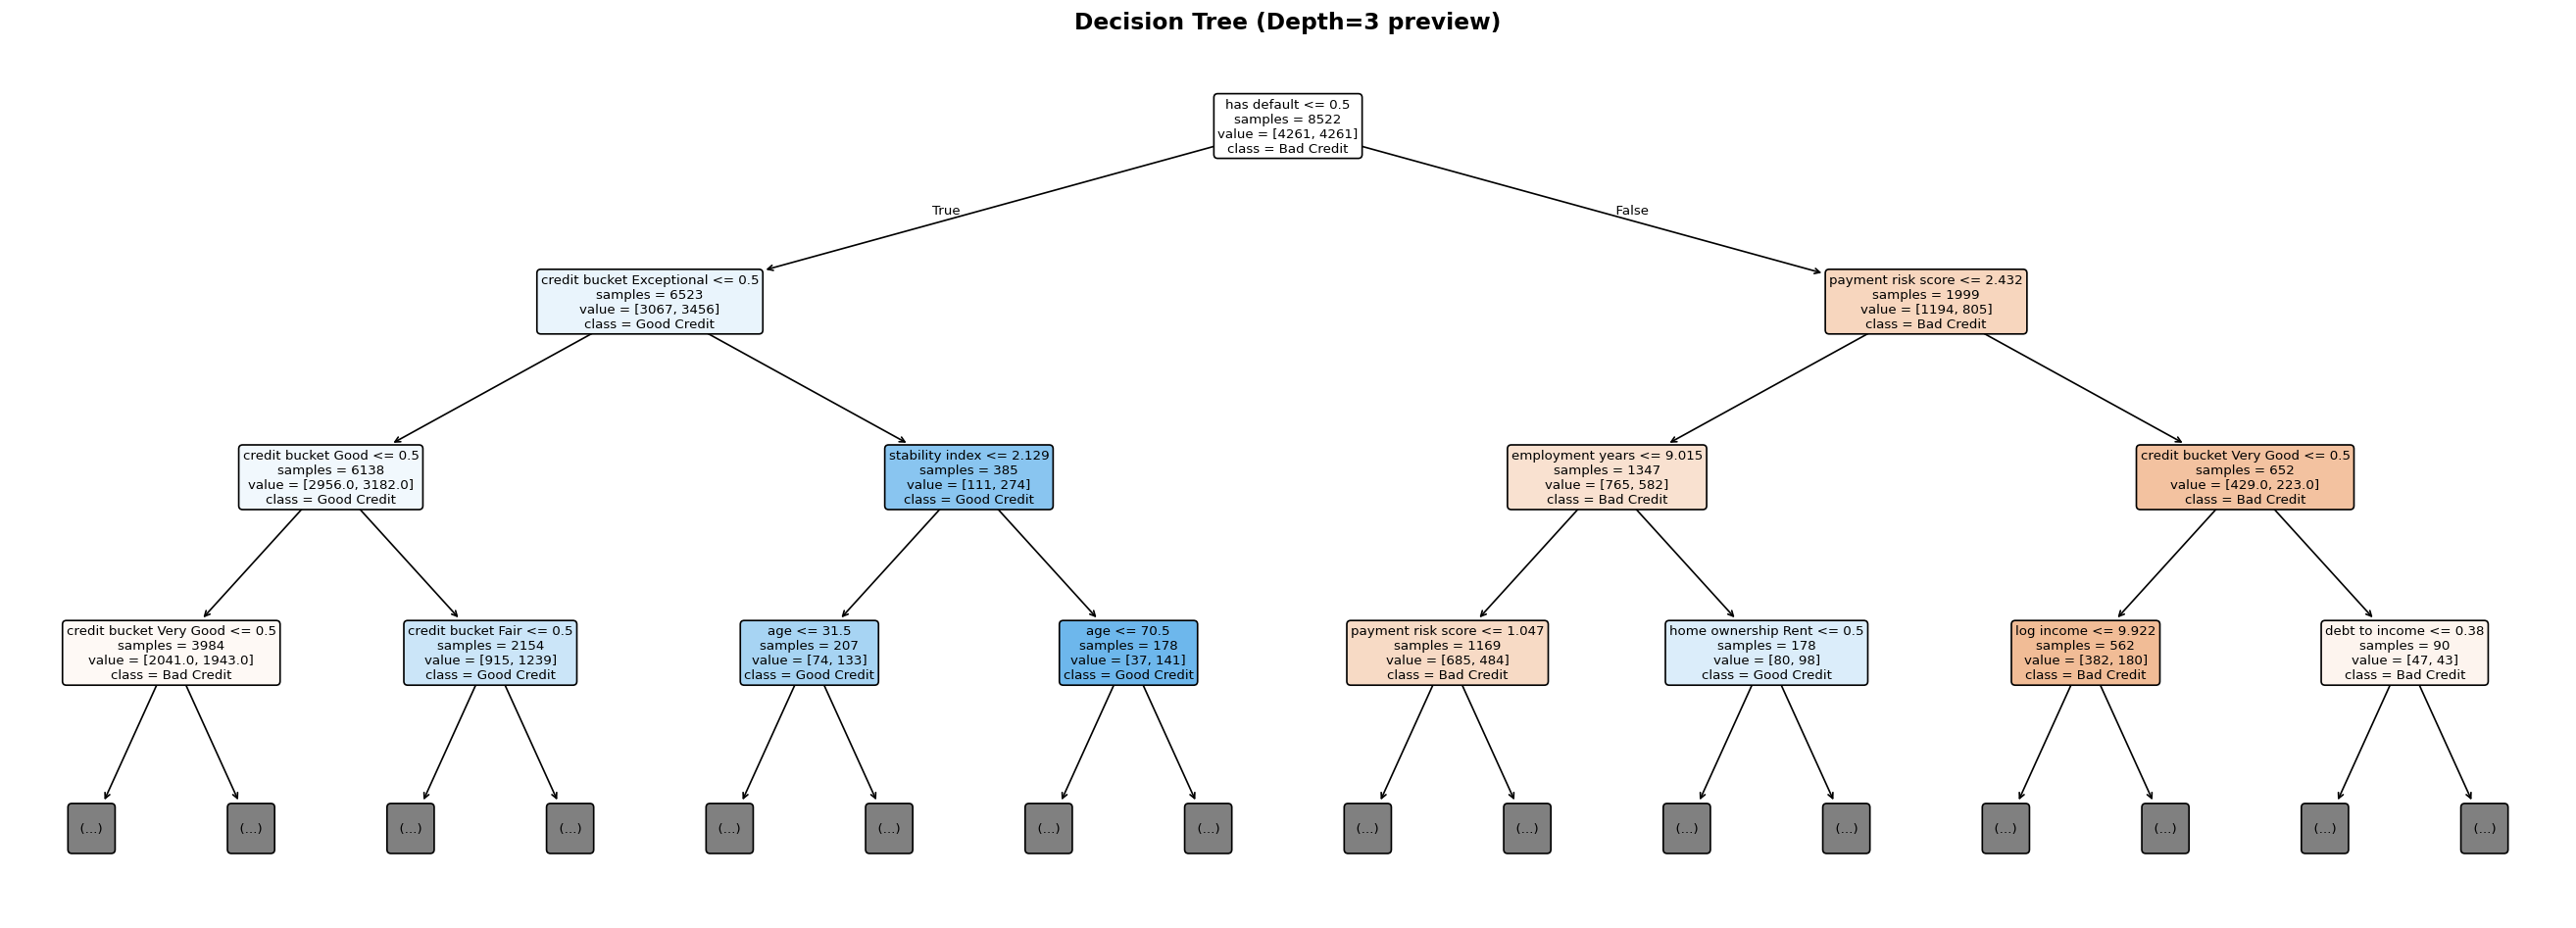

In [17]:
# --- Decision Tree Visualization (simplified) ---
dt_model = results['Decision Tree']['model']

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names=[f.replace('_', ' ') for f in feature_names],
    class_names=['Bad Credit', 'Good Credit'],
    filled=True,
    rounded=True,
    max_depth=3,
    ax=ax,
    fontsize=8,
    impurity=False
)
plt.title('Decision Tree (Depth=3 preview)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Prediction on New Data <a name='10'></a>

In [18]:
# --- Predict on New Applicants ---

def predict_creditworthiness(applicants_dict, model_name='XGBoost'):
    """
    Predict creditworthiness for new applicants.

    Parameters:
    -----------
    applicants_dict : list of dicts with applicant data
    model_name      : one of ['Logistic Regression', 'Decision Tree',
                               'Random Forest', 'Gradient Boosting', 'XGBoost']

    Returns:
    --------
    DataFrame with predictions and probabilities
    """
    df_new = pd.DataFrame(applicants_dict)

    # Feature engineering (same as training)
    df_new['income_to_loan_ratio']  = df_new['income'] / (df_new['loan_amount'] + 1)
    df_new['payment_risk_score']    = (df_new['num_late_payments'] * 0.4
                                       + df_new['num_defaults'] * 1.0
                                       + df_new['credit_utilization'] * 0.6)
    df_new['stability_index']       = (df_new['age'] * 0.4 + df_new['employment_years'] * 0.6) / 10
    df_new['log_income']            = np.log1p(df_new['income'])
    df_new['log_loan_amount']       = np.log1p(df_new['loan_amount'])
    df_new['credit_bucket']         = pd.cut(df_new['credit_score_raw'],
                                             bins=[299, 579, 669, 739, 799, 851],
                                             labels=['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional'])
    df_new['has_default']           = (df_new['num_defaults'] > 0).astype(int)
    df_new['high_utilization']      = (df_new['credit_utilization'] > 0.70).astype(int)
    df_new.drop(columns=['credit_score_raw'], inplace=True)

    # Encode categoricals
    df_new = pd.get_dummies(df_new,
                             columns=['loan_purpose', 'home_ownership', 'credit_bucket'],
                             drop_first=False)

    # Align columns with training set
    for col in X.columns:
        if col not in df_new.columns:
            df_new[col] = 0
    df_new = df_new[X.columns]

    # Scale if LR
    if model_name == 'Logistic Regression':
        df_input = scaler.transform(df_new)
    else:
        df_input = df_new.values

    model_obj = results[model_name]['model']
    preds = model_obj.predict(df_input)
    probs = model_obj.predict_proba(df_input)[:, 1]

    return pd.DataFrame({
        'Applicant':       [f'Applicant {i+1}' for i in range(len(applicants_dict))],
        'Prediction':      ['✅ Creditworthy' if p == 1 else '❌ Not Creditworthy' for p in preds],
        'Prob_Creditworthy': probs.round(4),
        'Risk_Level':      ['Low' if p > 0.75 else ('Medium' if p > 0.45 else 'High') for p in probs]
    })


# --- Test with 3 sample applicants ---
new_applicants = [
    {  # Good profile
        'age': 45, 'income': 90000, 'employment_years': 12, 'num_credit_lines': 6,
        'credit_utilization': 0.18, 'num_late_payments': 0, 'num_defaults': 0,
        'debt_to_income': 0.20, 'loan_amount': 15000, 'loan_purpose': 'Home',
        'home_ownership': 'Own', 'credit_score_raw': 760
    },
    {  # Risky profile
        'age': 24, 'income': 28000, 'employment_years': 1, 'num_credit_lines': 2,
        'credit_utilization': 0.88, 'num_late_payments': 5, 'num_defaults': 2,
        'debt_to_income': 0.85, 'loan_amount': 25000, 'loan_purpose': 'Personal',
        'home_ownership': 'Rent', 'credit_score_raw': 490
    },
    {  # Borderline profile
        'age': 33, 'income': 52000, 'employment_years': 4, 'num_credit_lines': 4,
        'credit_utilization': 0.48, 'num_late_payments': 2, 'num_defaults': 0,
        'debt_to_income': 0.40, 'loan_amount': 18000, 'loan_purpose': 'Auto',
        'home_ownership': 'Mortgage', 'credit_score_raw': 640
    }
]

predictions = predict_creditworthiness(new_applicants, model_name='XGBoost')
print('\n🎯 CREDIT SCORING PREDICTIONS')
print('=' * 60)
print(predictions.to_string(index=False))
print('=' * 60)


🎯 CREDIT SCORING PREDICTIONS
  Applicant         Prediction  Prob_Creditworthy Risk_Level
Applicant 1     ✅ Creditworthy             0.6533     Medium
Applicant 2 ❌ Not Creditworthy             0.2406       High
Applicant 3 ❌ Not Creditworthy             0.4422       High


In [19]:
# --- Final Summary Dashboard ---
print('\n' + '='*60)
print('        📋 CREDIT SCORING MODEL — FINAL SUMMARY')
print('='*60)
print(f'  Dataset Size:        {N:,} records')
print(f'  Features (engineered): {len(X.columns)}')
print(f'  Train / Test Split:  80% / 20%')
print(f'  Imbalance Handling:  SMOTE Oversampling')
print(f'  Scaler:              RobustScaler')
print()
print('  Model Performance (Test Set):')
print(f'  {"-"*50}')
for name, res in results.items():
    marker = ' 🏆' if name == best_name else ''
    print(f'  {name:22s} | AUC: {res["roc_auc"]:.4f} | F1: {res["f1"]:.4f}{marker}')
print(f'  {"-"*50}')
print(f'\n  🏆 Best Model: {best_name}')
print(f'     ROC-AUC:  {results[best_name]["roc_auc"]:.4f}')
print(f'     F1-Score: {results[best_name]["f1"]:.4f}')
print(f'     Accuracy: {results[best_name]["accuracy"]:.4f}')
print('='*60)


        📋 CREDIT SCORING MODEL — FINAL SUMMARY
  Dataset Size:        10,000 records
  Features (engineered): 29
  Train / Test Split:  80% / 20%
  Imbalance Handling:  SMOTE Oversampling
  Scaler:              RobustScaler

  Model Performance (Test Set):
  --------------------------------------------------
  Logistic Regression    | AUC: 0.6040 | F1: 0.5153 🏆
  Decision Tree          | AUC: 0.5601 | F1: 0.5228
  Random Forest          | AUC: 0.5874 | F1: 0.5205
  Gradient Boosting      | AUC: 0.5758 | F1: 0.5003
  XGBoost                | AUC: 0.5639 | F1: 0.4819
  --------------------------------------------------

  🏆 Best Model: Logistic Regression
     ROC-AUC:  0.6040
     F1-Score: 0.5153
     Accuracy: 0.5890
